In [13]:
import sys
import os

cwd = os.getcwd()
print(cwd)
project_root = os.path.abspath(os.path.join(cwd, "../../.."))
sys.path.append(project_root)
sys.path.append(os.path.join(cwd, "XCP-explain"))

import cpmpy as cp

/Users/macbookpro/Desktop/cpmpy/cpmpy/tools/explain


In [14]:
# reload cpmpy if changes made
import importlib
importlib.reload(cp)

<module 'cpmpy' from '/Users/macbookpro/Desktop/cpmpy/cpmpy/__init__.py'>

In [6]:
# test diversity definitions

from cpmpy.tools.explain.utils import diversity, diversity_matrix
importlib.reload(cp.tools.explain.utils)

A = {1, 2, 3, 4}
B = {3, 4, 5, 6, 7, 8}
C = {1, 3, 4, 5, 6}

assert diversity(A, B, "Jaccard") == 0.75
assert diversity(A, B, "overlap") == 0.5
assert diversity(A, B, "set difference") == 0.75

assert diversity(A, C, "Jaccard") == 0.5
assert diversity(A, C, "overlap") == 0.25

assert diversity(A, A, "Jaccard") == 0
assert diversity(A, A, "overlap") == 0
assert diversity(A, A, "set difference") == 0
assert diversity(B, B) == 0

# diversity(B, C, "Jaccard")

# print(diversity_matrix([A, B, C], "Jaccard"))
# print(diversity_matrix([A, B, C], "overlap"))


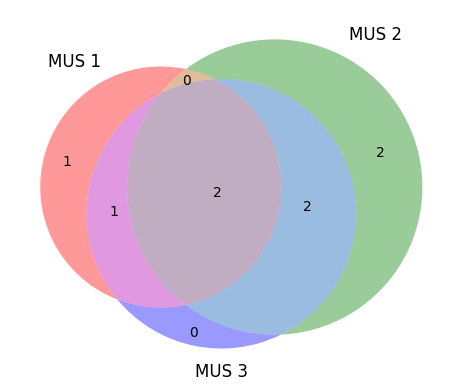

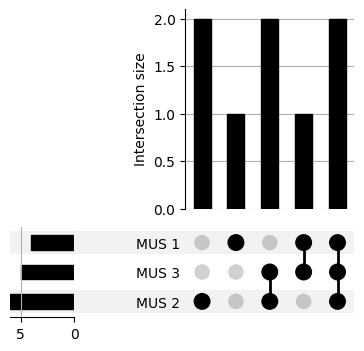

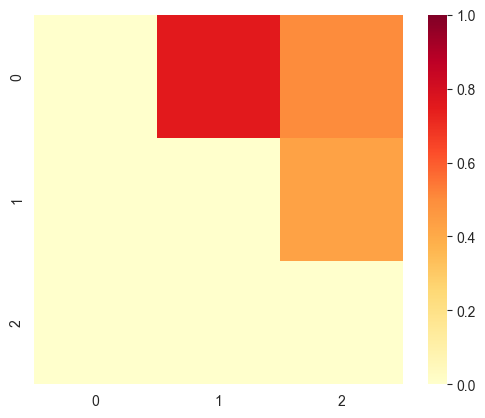

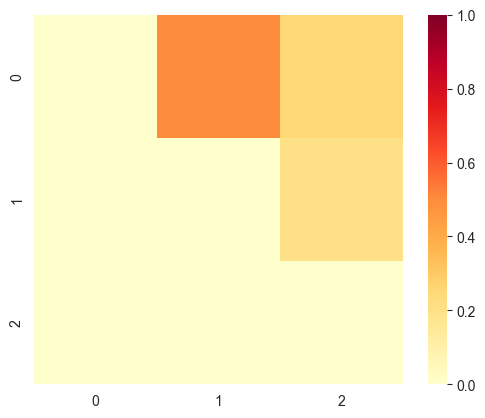

In [7]:
# visualization tests/examples
from cpmpy.tools.explain.visualize_diversity import *
# to ignore the pandas FutureWarning when using UpSet from_contents
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)


visualize_venn([A,B,C])
visualize_upset([A,B,C])
d1 = diversity_matrix([A,B,C],"Jaccard")
d2 = diversity_matrix([A,B,C],"overlap")
visualize_heatmap(d1)
visualize_heatmap(d2)


# Test Algorithms

In [8]:
# setup nurse rostering model

from visualize import *
from read_data import get_data
from factory import *
from cpmpy.tools.explain import marco
from cpmpy.tools.explain.diverse_enumeration import *


instance = os.path.join("XCP-explain","Benchmarks/CustomInstance.txt")
data = get_data(instance)
factory = NurseSchedulingFactory(data)

model, nurse_view = factory.get_decision_model()


top_indx, top_muses, avg, matrix =  marco_until_diverse(model.constraints, 4, 10)



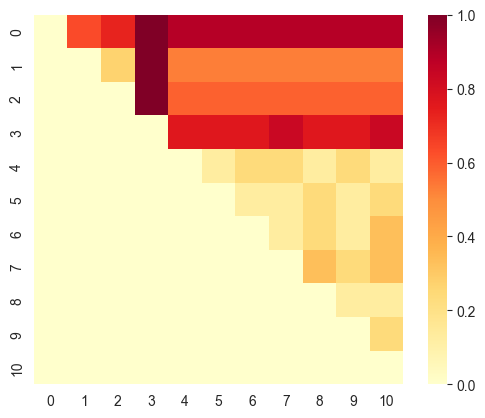

The most diverse combination are MUSes (0, 2, 3, 7), with average diversity of 0.839621707268766.


In [9]:
visualize_heatmap(matrix)
print(f"The most diverse combination are MUSes {top_indx}, with average diversity of {avg}.")

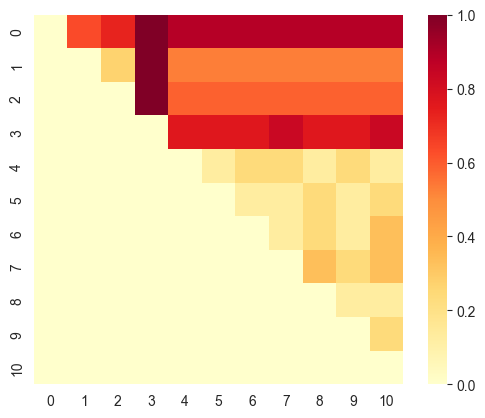

The most diverse combination are MUSes (0, 2, 3, 7), with average diversity of 0.839621707268766.


In [10]:
top_indx, top_muses, avg, matrix =  marco_select_top_k(model.constraints, 4, 10)

visualize_heatmap(matrix)
print(f"The most diverse combination are MUSes {top_indx}, with average diversity of {avg}.")


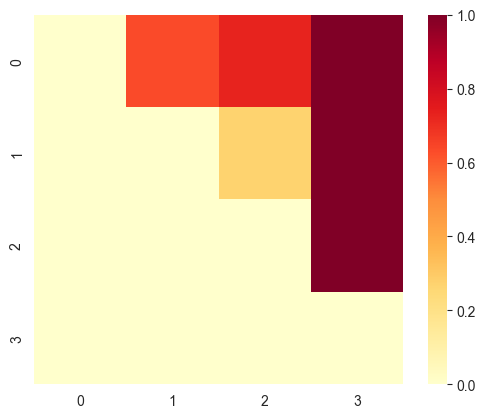

The average diversity of the first 4 MUSes generated by MARCO is: 0.7727272727272728


In [19]:
result = []
for i, (kind, subset) in enumerate(marco_diverse_greedy(model.constraints, solver="exact", map_solver="exact", return_mcs=False)):
    result.append(frozenset(subset))
    if i == 3:
        break

matrix = diversity_matrix(result)
visualize_heatmap(matrix)

avg = matrix[np.triu_indices_from(matrix, k=1)].mean()
print(f"The average diversity of the first {len(result)} MUSes generated by MARCO is: {avg}")